
![Imagen_1](https://drive.google.com/uc?export=view&id=1mk_GY7Nphzk0pwQpGsku64DNox4nfll-)


## **Informacion del Dataset**

El dataset seleccionado es [*"Bone Break Classification Image Dataset"*](https://www.kaggle.com/datasets/pkdarabi/bone-break-classification-image-dataset). Este está enfocado en la detección, clasificación y localización de fracturas óseas. Este dataset esta compuesto por imagenes de **rayos X.**

## **Composicion del Dataset**
* **Total Imagenes X-ray**: 1129
  * **Imagenes de entrenamiento**: 989 en formato *".jpg"*
  * **Imagenes de prueba**:140 en formato *".jpg"*

* **Partes del cuerpo que estan en el dataset**: Codo, dedo, antebrazo, húmero, hombro, fémur, tibia, rodilla, cadera, muñeca, médula espinal y otras muestras de huesos sano.
* **Tipos de fracturas**:fracturas por avulsión,conminutas, fracturas-luxaciones, fracturas en tallo verde, hairline, impactadas, longitudinales, oblicuas, patológicas y espirales.

# **Cargar las librerias y el dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import os
import shutil
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [ ]:
!git clone https://github.com/Pipevg1801/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays.git
base_dir = '/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/'
print(f"La direccion del dataset es: {base_dir}")

Cloning into 'FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays'...
remote: Enumerating objects: 1167, done.
remote: Counting objects: 100% (1167/1167), done.
remote: Compressing objects: 100% (1039/1039), done.
remote: Total 1167 (delta 129), reused 1165 (delta 127), pack-reused 0 (from 0)
Receiving objects: 100% (1167/1167), 28.26 MiB | 28.74 MiB/s, done.
Resolving deltas: 100% (129/129), done.
La direccion del dataset es: /content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/


# **Visualizacion de una muestra de imagenes estandarizadas**



**Seleccionar todas las imagenes para el entrenamiento**

Primero, se leen todos los subfolders de "Train" cada una de las carpetas de fracturas

In [ ]:
train_directories = []
for root, dirs, files in os.walk(base_dir):
    for dir_name in dirs:
        if dir_name == 'Train':
            train_path = os.path.join(root, dir_name)
            train_directories.append(train_path)
print("Found 'Train' directories:")
for path in train_directories:
    print(path)

Found 'Train' directories:
/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classification/Greenstick fracture/Train
/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classification/Fracture Dislocation/Train
/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classification/Avulsion fracture/Train
/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classification/Spiral Fracture/Train
/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classification/Pathological fracture/Train
/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classification/Comminuted fracture/Train
/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classification/Hairline Fracture/Train
/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classificat

Se hace el resize de las imagenes Train a 256x256 $[px]$ en formato grayscale

In [ ]:
IMG_WIDTH = 256
IMG_HEIGHT = 256
all_images_arrays = []

for train_dir in train_directories:
    for root, _, files in os.walk(train_dir):
        for file in files:
            if file.lower().endswith(('.jpg')):
                img_path = os.path.join(root, file)
                img = Image.open(img_path)
                img = img.convert('L')
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                img_array = np.array(img)
                all_images_arrays.append(img_array)

print(f"Images obtenidas para el entrenamiento {len(all_images_arrays)}")

Images obtenidas para el entrenamiento 989


Se grafican 10 imagenes para comprobar que son correctas

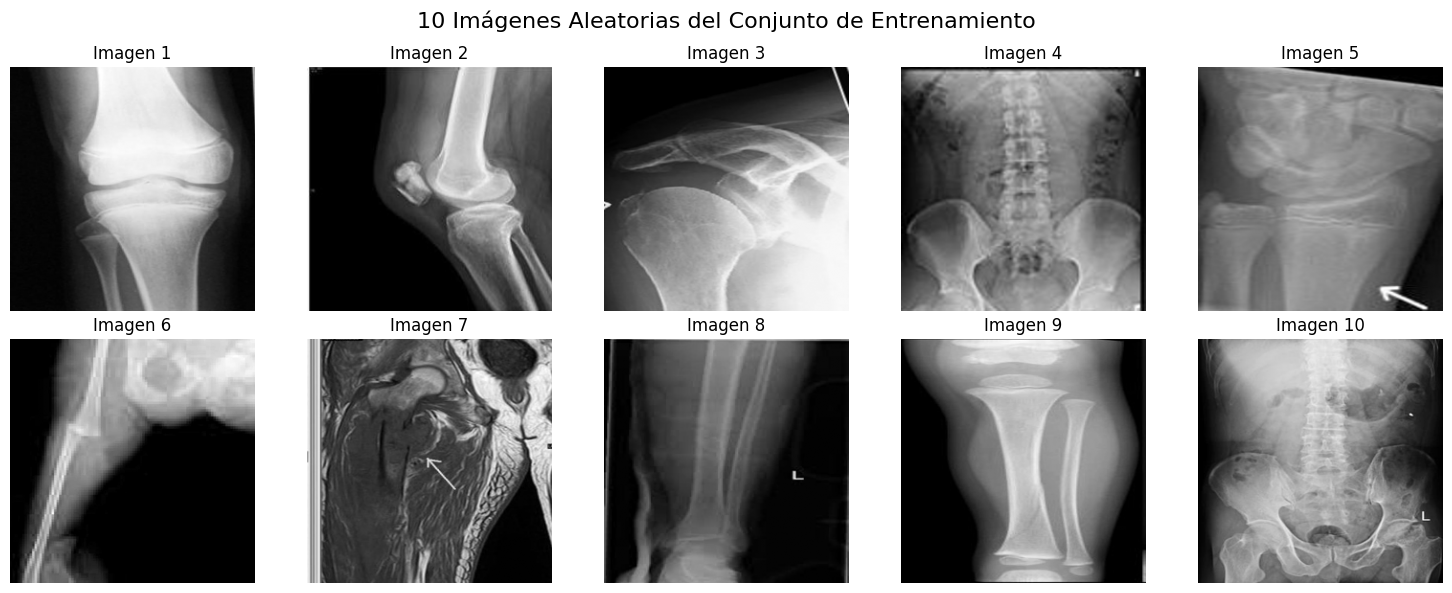

In [ ]:
np.random.seed(1)
num_images_to_show = 10
random_indices = np.random.choice(len(all_images_arrays), num_images_to_show, replace=False)

random_images = [all_images_arrays[i] for i in random_indices]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('10 Imágenes Aleatorias del Conjunto de Entrenamiento', fontsize=16)
axes_flat = axes.flatten()

for i, img_array in enumerate(random_images):
    axes_flat[i].imshow(img_array,cmap='gray')
    axes_flat[i].axis('off')
    axes_flat[i].set_title(f'Imagen {i+1}')

plt.tight_layout()
plt.show()

Se extraen estadisticas y se hacen los histogramas de mean $\mu$ y STD $\sigma$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

all_images_arrays = np.array(all_images_arrays)

means = all_images_arrays.mean(axis=(1, 2))
vars_ = all_images_arrays.std(axis=(1, 2))

print(f"media{(means)}\n varianza{(vars_)}")

media[173.20504761  98.20173645  73.45588684  95.87283325 112.52168274
  74.74867249  86.75361633 144.01782227  64.06825256 104.3591156
 135.52696228  79.57460022  63.66464233 101.59658813 128.23321533
  95.22344971  93.27635193  78.64826965  74.5460968   81.34104919
 104.8132019   51.72229004  89.95429993  56.00453186  66.80316162
 103.3271637   75.10662842 117.9335022   39.8369751  103.57008362
  77.70320129  79.30073547  43.16558838  76.89190674  50.74499512
  74.0756073   37.95767212  37.35842896  76.88357544  70.87518311
 117.28596497  69.00674438 103.01255798  57.27732849  98.69792175
  41.82463074  63.74568176  64.51516724 122.83604431  78.17602539
  61.90290833 110.00282288  38.41307068  38.74562073  86.19828796
  53.09608459 107.61656189  62.19032288 104.72402954  62.61408997
  88.53775024 118.70082092  74.73448181  23.5643158  118.16984558
  92.66917419  83.26661682  32.87831116 120.82730103  93.75280762
  79.10997009 108.07470703  64.92529297  53.1723175   51.46650696
  75.6

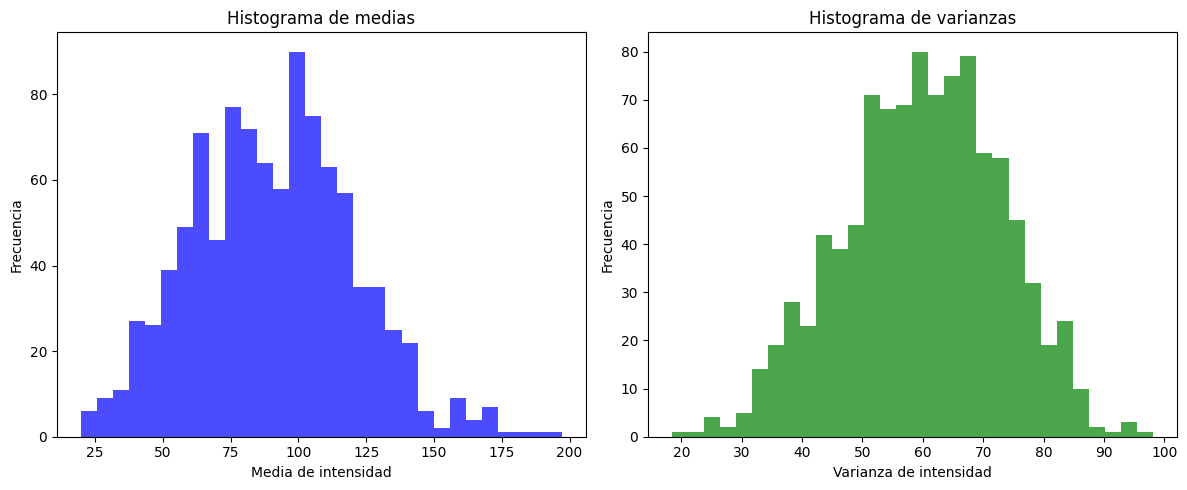

In [ ]:
plt.figure(figsize=(12, 5))

# Histograma de medias
plt.subplot(1, 2, 1)
plt.hist(means, bins=30, color='blue', alpha=0.7)
plt.title('Histograma de medias')
plt.xlabel('Media de intensidad')
plt.ylabel('Frecuencia')

# Histograma de varianzas
plt.subplot(1, 2, 2)
plt.hist(vars_, bins=30, color='green', alpha=0.7)
plt.title('Histograma de varianzas')
plt.xlabel('Varianza de intensidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


# **Particionado 80/20 Todas las clases**



Los datos actuales ya se encuentran particionados pero, primero esta el nombre de la categoria y luego la division del train y el test. para esto ejecutaremos la siguiente funcion para modificarlo

In [ ]:
original_data_path = '/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classification/'
new_data_path = '/content/Reorganized-FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/'
fracture_types = [
    "Avulsion fracture", "Comminuted fracture", "Fracture Dislocation",
    "Greenstick fracture", "Hairline Fracture", "Impacted fracture",
    "Longitudinal fracture", "Oblique fracture", "Pathological fracture",
    "Spiral Fracture"
]

def reorganize_dataset():
    for f_type in fracture_types:
        current_type_path = Path(original_data_path) / f_type
        all_images = (list(current_type_path.rglob('*.jpg')) +
                      list(current_type_path.rglob('*.jpeg')) +
                      list(current_type_path.rglob('*.png')))

        if not all_images:
            print(f"Sin imagenes en {f_type}.")
            continue

        train_files, test_files = train_test_split(all_images, test_size=0.20, random_state=42)

        for split, files in [('Train', train_files), ('Test', test_files)]:
            target_dir = Path(new_data_path) / split / f_type
            target_dir.mkdir(parents=True, exist_ok=True)

            for f in files:
                shutil.copy(f, target_dir / f.name)

    print(f"Nueva distribucion en: {new_data_path}")

reorganize_dataset()

Nueva distribucion en: /content/Reorganized-FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/


**Preparación del nuevo Dataset**

Primero, cargaremos las imágenes del dataset reorganizado y sus respectivas etiquetas. Luego, aplanaremos las imágenes para que sean compatibles con los modelos de scikit-learn y codificaremos las etiquetas numéricamente.

In [ ]:
def load_and_preprocess_images(data_path, img_width, img_height):
    images = []
    labels = []
    for split_dir in ['Train', 'Test']:
        split_path = Path(data_path) / split_dir
        for f_type in os.listdir(split_path):
            if (split_path / f_type).is_dir():
                category_path = split_path / f_type
                for img_file in os.listdir(category_path):
                    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        img_path = category_path / img_file
                        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                        img = cv2.resize(img, (img_width, img_height))
                        images.append(img)
                        labels.append(f_type)
    return np.array(images), np.array(labels)

X, y = load_and_preprocess_images(new_data_path, IMG_WIDTH, IMG_HEIGHT)

X_norm = X.astype('float32') / 255.0
X_flattened = X_norm.reshape(len(X_norm), -1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_flattened, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Number of classes: {len(le.classes_)}")
results = {}


Shape of X_train: (903, 65536)
Shape of X_test: (226, 65536)
Number of classes: 10


**Balance de Clases**

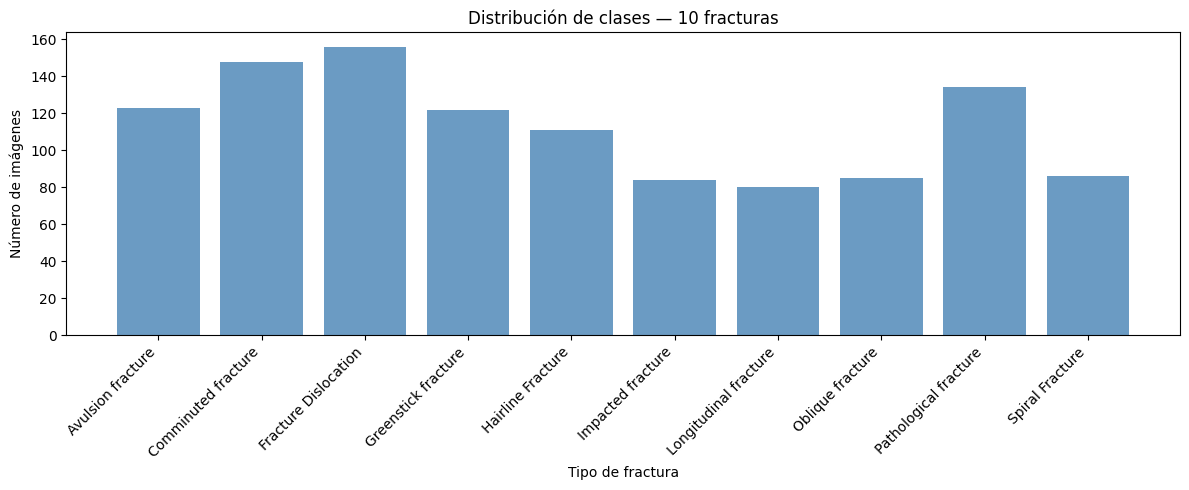

Conteo por clase:
  Avulsion fracture: 123
  Comminuted fracture: 148
  Fracture Dislocation: 156
  Greenstick fracture: 122
  Hairline Fracture: 111
  Impacted fracture: 84
  Longitudinal fracture: 80
  Oblique fracture: 85
  Pathological fracture: 134
  Spiral Fracture: 86


In [ ]:
unique, counts = np.unique(y_encoded, return_counts=True)
class_dist = dict(zip(le.classes_, counts))

plt.figure(figsize=(12, 5))
plt.bar(class_dist.keys(), class_dist.values(), color='steelblue', alpha=0.8)
plt.title('Distribución de clases — 10 fracturas')
plt.xlabel('Tipo de fractura')
plt.ylabel('Número de imágenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Conteo por clase:")
for k, v in class_dist.items():
    print(f"  {k}: {v}")


**Árbol de Decisión (Decision Tree)**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
error_dt = 1 - accuracy_dt

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Error: {error_dt:.4f}")
results['Decision Tree'] = {'Accuracy': accuracy_dt, 'Error': error_dt}

Decision Tree Accuracy: 0.2080
Decision Tree Error: 0.7920


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
error_rf = 1 - accuracy_rf

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Error: {error_rf:.4f}")
results['Random Forest'] = {'Accuracy': accuracy_rf, 'Error': error_rf}

Random Forest Accuracy: 0.3496
Random Forest Error: 0.6504


**Support Vector Machine (SVM)**

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='poly', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
error_svm = 1 - accuracy_svm

print(f"SVM Accuracy: {accuracy_svm:.4f}")
print(f"SVM Error: {error_svm:.4f}")
results['SVM'] = {'Accuracy': accuracy_svm, 'Error': error_svm}

SVM Accuracy: 0.3053
SVM Error: 0.6947


**Perceptrón Multicapa (MLP) con TensorFlow**

In [ ]:
X_train_nn = X_train.astype('float32')
X_test_nn = X_test.astype('float32')

num_classes = len(le.classes_)

mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

mlp_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

epochs = 30
batch_size = 32

# Guarda el mejor modelo
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_mlp_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training MLP model...")
history = mlp_model.fit(
    X_train_nn, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1,
    callbacks=[model_checkpoint_callback]
)

loss_mlp, accuracy_mlp = mlp_model.evaluate(X_test_nn, y_test, verbose=0)
error_mlp = 1 - accuracy_mlp

print(f"MLP Accuracy: {accuracy_mlp:.4f}")
print(f"MLP Error: {error_mlp:.4f}")
results['MLP TensorFlow'] = {'Accuracy': accuracy_mlp, 'Error': error_mlp}

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training MLP model...
Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.1228 - loss: 14.0909
Epoch 1: val_accuracy improved from None to 0.15385, saving model to best_mlp_model.keras

Epoch 1: finished saving model to best_mlp_model.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 416ms/step - accuracy: 0.1244 - loss: 9.7456 - val_accuracy: 0.1538 - val_loss: 3.8181
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.1482 - loss: 3.7357
Epoch 2: val_accuracy did not improve from 0.15385
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 344ms/step - accuracy: 0.1502 - loss: 3.5872 - val_accuracy: 0.1209 - val_loss: 2.8699
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.2042 - loss: 2.5653
Epoch 3: val_accuracy did not improve from 0.15385
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 295ms/step - accuracy: 0.1958 - loss: 2.5336 - val_accuracy: 0.1099 - val_loss: 2.7084
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.1964 - loss: 2.2923
Epoch 4: val_accuracy improved fr

**Evaluacion del MLP**


In [ ]:
best_mlp_model = tf.keras.models.load_model('best_mlp_model.keras')

loss_mlp_best, test_accuracy_best_mlp = best_mlp_model.evaluate(X_test_nn, y_test, verbose=0)
error_mlp_best = 1 - test_accuracy_best_mlp

results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.index.name = 'Model'

results['MLP TensorFlow (Best Model)'] = {'Accuracy': test_accuracy_best_mlp, 'Error': error_mlp_best}
print(f"Best MLP Model Test Accuracy: {test_accuracy_best_mlp:.4f}")
print(f"Best MLP Model Test Loss: {loss_mlp_best:.4f}")

Best MLP Model Test Accuracy: 0.1903
Best MLP Model Test Loss: 2.4993


**Graficas del MLP**

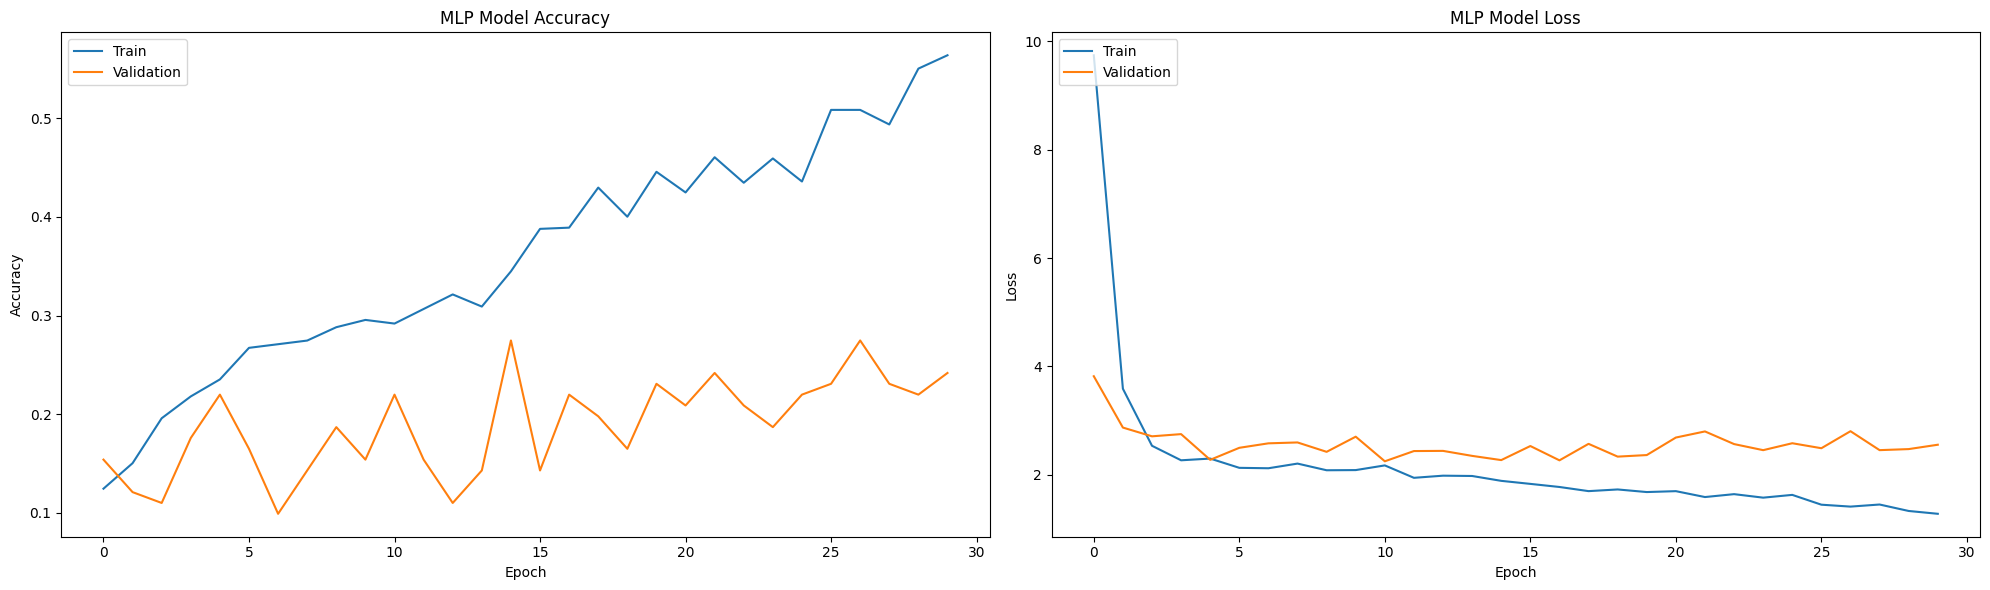

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('MLP Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('MLP Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

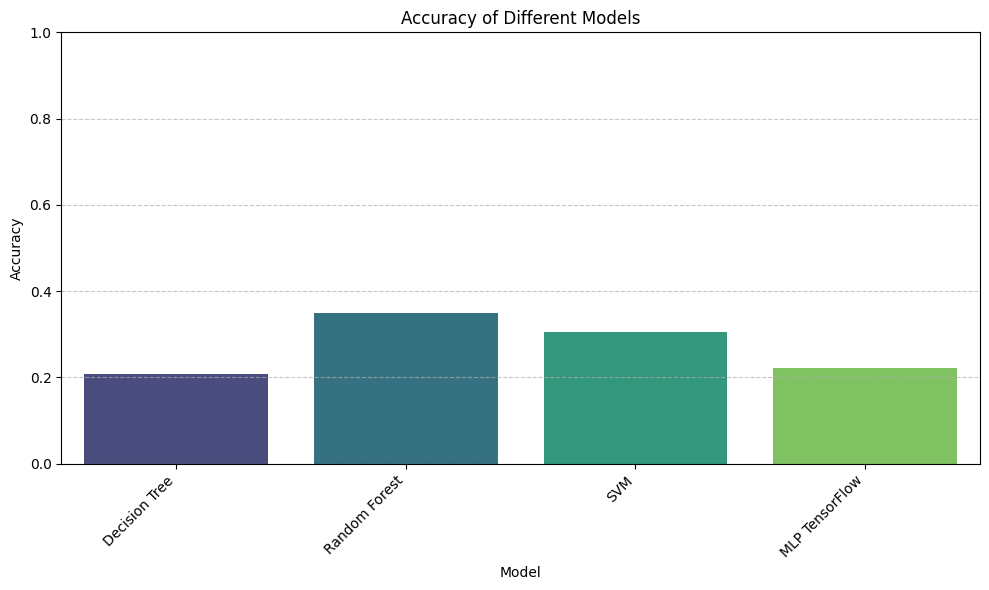

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y='Accuracy', data=results_df, palette='viridis', hue=results_df.index)
plt.title('Accuracy of Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Visualización del comportamiento de los modelos**

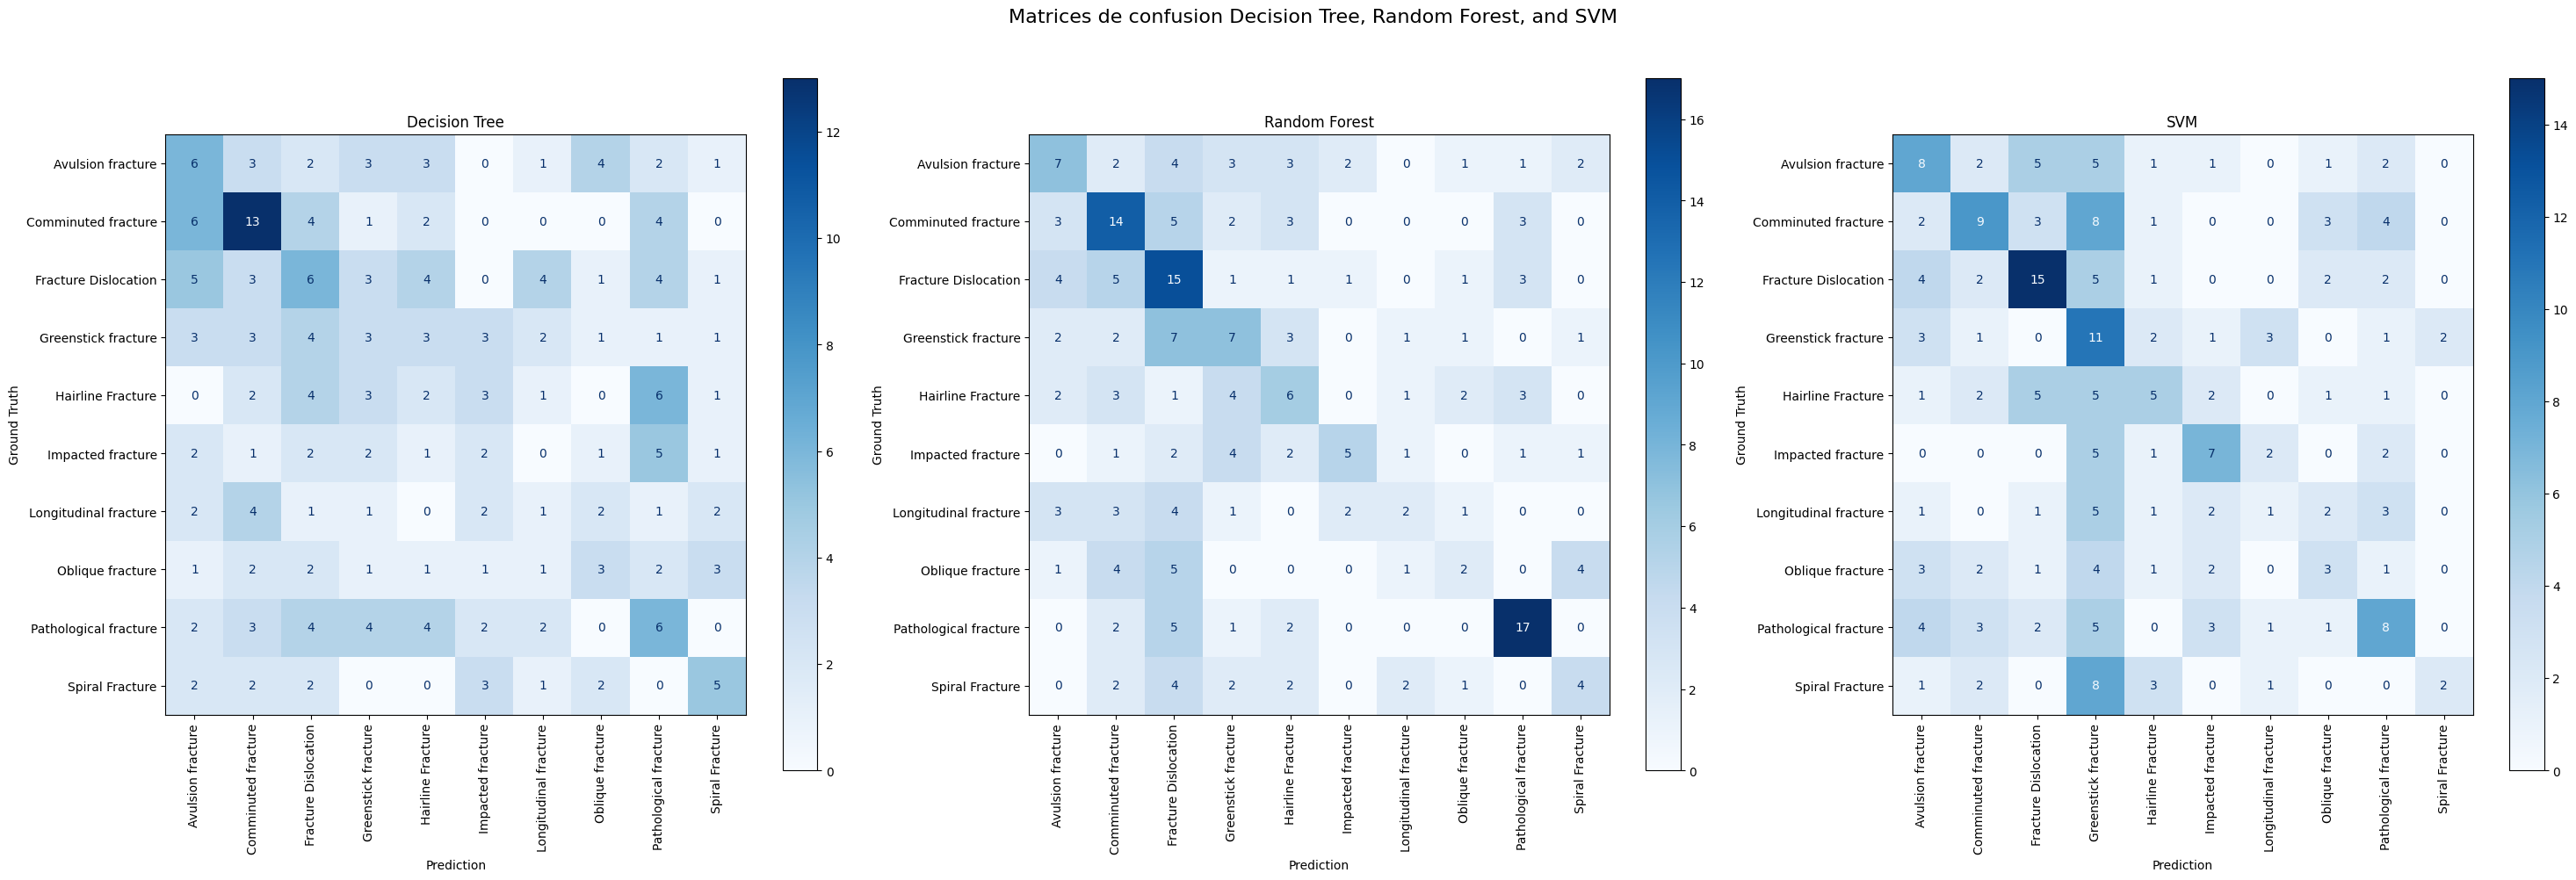

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix_subplot(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    ax.set_title(title)
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Ground Truth')

class_names = le.classes_

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
fig.suptitle('Matrices de confusion Decision Tree, Random Forest, and SVM', fontsize=16)

plot_confusion_matrix_subplot(y_test, y_pred_dt, class_names, 'Decision Tree', axes[0])

plot_confusion_matrix_subplot(y_test, y_pred_rf, class_names, 'Random Forest', axes[1])

plot_confusion_matrix_subplot(y_test, y_pred_svm, class_names, 'SVM', axes[2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **Particionado 80/20 clases seleccionadas**


Debido al bajo desempeño del modelo (basandonos en la metrica del accuracy) decidimos hacer una reduccion del numero de clases, quitando aquellas mas problematicas para ver si mejoraba el rendimiento del modelo, en este caso quitamos las siguientes categorias:

* Hairline fracture
* Fracture Dislocation
* Impacted fracture
* Oblique fracture
* Pathological fracture
* Spiral Fracture
* Longitudinal fracture
* Avulsion fracture


In [ ]:
def reorganize_selected_dataset(input_path, output_path, selected_fracture_types):
    for f_type in selected_fracture_types:
        current_type_path = Path(input_path) / f_type
        all_images = (list(current_type_path.rglob('*.jpg')) +
                      list(current_type_path.rglob('*.jpeg')) +
                      list(current_type_path.rglob('*.png')))
        if not all_images:
            print(f"Sin imagenes en {f_type}.")
            continue
        train_files, test_files = train_test_split(all_images, test_size=0.20, random_state=42)
        for split, files in [('Train', train_files), ('Test', test_files)]:
            target_dir = Path(output_path) / split / f_type
            target_dir.mkdir(parents=True, exist_ok=True)
            for f in files:
                shutil.copy(f, target_dir / f.name)
    print(f"Nueva distribucion en: {output_path}")


In [ ]:
original_data_path = '/content/FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/Bone Break Classification/'
Selected_classes_path = '/content/Selected-classes-FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/'
fracture_types_selected = [
    "Comminuted fracture", "Fracture Dislocation"
]

reorganize_selected_dataset(original_data_path, Selected_classes_path, fracture_types_selected)


Nueva distribucion en: /content/Selected-classes-FractureFinder-Automated-Classification-of-Bone-Breaks-in-X-rays/


**Preparación del Dataset**

In [ ]:
X_selected, y_selected = load_and_preprocess_images(Selected_classes_path, IMG_WIDTH, IMG_HEIGHT)

X_norm_selected = X_selected.astype('float32') / 255.0
X_flattened_selected = X_norm_selected.reshape(len(X_norm_selected), -1)

le_selected = LabelEncoder()
y_encoded_selected = le_selected.fit_transform(y_selected)

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_flattened_selected, y_encoded_selected, test_size=0.2, random_state=42, stratify=y_encoded_selected)

print(f"Shape of X_train: {X_train_selected.shape}")
print(f"Shape of X_test: {X_test_selected.shape}")
print(f"Number of classes: {len(le_selected.classes_)}")
results_selected = {}


Shape of X_train: (243, 65536)
Shape of X_test: (61, 65536)
Number of classes: 2


**Distribución y balance de clases seleccionadas**


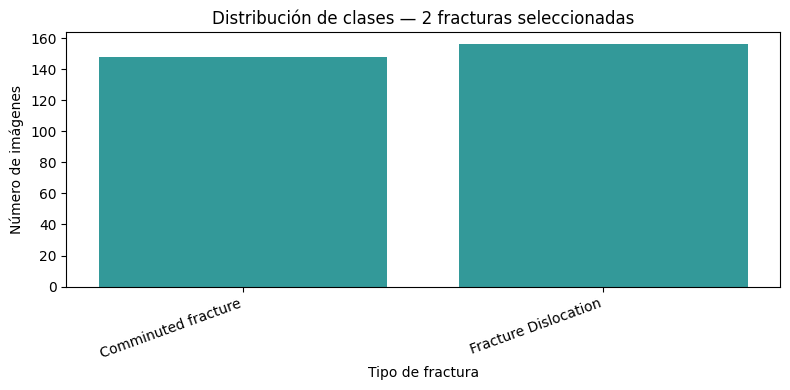

Conteo por clase:
  Comminuted fracture: 148
  Fracture Dislocation: 156


In [ ]:
unique_s, counts_s = np.unique(y_encoded_selected, return_counts=True)
class_dist_s = dict(zip(le_selected.classes_, counts_s))

plt.figure(figsize=(8, 4))
plt.bar(class_dist_s.keys(), class_dist_s.values(), color='teal', alpha=0.8)
plt.title('Distribución de clases — 2 fracturas seleccionadas')
plt.xlabel('Tipo de fractura')
plt.ylabel('Número de imágenes')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print("Conteo por clase:")
for k, v in class_dist_s.items():
    print(f"  {k}: {v}")


**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model_selected = DecisionTreeClassifier(random_state=42)
dt_model_selected.fit(X_train_selected, y_train_selected)

y_pred_dt_selected = dt_model_selected.predict(X_test_selected)

accuracy_dt_selected = accuracy_score(y_test_selected, y_pred_dt_selected)
error_dt_selected = 1 - accuracy_dt_selected

print(f"Decision Tree Accuracy: {accuracy_dt_selected:.4f}")
print(f"Decision Tree Error: {error_dt_selected:.4f}")
results_selected['Decision Tree'] = {'Accuracy': accuracy_dt_selected, 'Error': error_dt_selected}

Decision Tree Accuracy: 0.6230
Decision Tree Error: 0.3770


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_selected.fit(X_train_selected, y_train_selected)

y_pred_rf_selected = rf_model_selected.predict(X_test_selected)

accuracy_rf_selected = accuracy_score(y_test_selected, y_pred_rf_selected)
error_rf_selected = 1 - accuracy_rf_selected

print(f"Random Forest Accuracy: {accuracy_rf_selected:.4f}")
print(f"Random Forest Error: {error_rf_selected:.4f}")
results_selected['Random Forest'] = {'Accuracy': accuracy_rf_selected, 'Error': error_rf_selected}

Random Forest Accuracy: 0.8033
Random Forest Error: 0.1967


**Support Vector Machine (SVM)**

In [ ]:
from sklearn.svm import SVC

svm_model_selected = SVC(kernel='poly', random_state=42)
svm_model_selected.fit(X_train_selected, y_train_selected)

y_pred_svm_selected = svm_model_selected.predict(X_test_selected)

accuracy_svm_selected = accuracy_score(y_test_selected, y_pred_svm_selected)
error_svm_selected = 1 - accuracy_svm_selected

print(f"SVM Accuracy: {accuracy_svm_selected:.4f}")
print(f"SVM Error: {error_svm_selected:.4f}")
results_selected['SVM'] = {'Accuracy': accuracy_svm_selected, 'Error': error_svm_selected}

SVM Accuracy: 0.6885
SVM Error: 0.3115


**Perceptrón Multicapa (MLP)**

In [ ]:
X_train_nn_selected = X_train_selected.astype('float32') / 255.0
X_test_nn_selected = X_test_selected.astype('float32') / 255.0

num_classes_selected = len(le_selected.classes_)

mlp_model_selected = Sequential([
    Dense(256, activation='elu', input_shape=(X_train_nn_selected.shape[1],)),
    Dense(128, activation='elu'),
    Dense(64, activation='elu'),
    Dense(32, activation='elu'),
    Dense(16, activation='elu'),
    Dense(num_classes_selected, activation='softmax')
])

mlp_model_selected.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

epochs = 40
batch_size = 32

# Guarda el mejor modelo
model_checkpoint_callback_selected = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_mlp_model_selected.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training MLP model...")
history_selected = mlp_model_selected.fit(
    X_train_nn_selected, y_train_selected,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1,
    callbacks=[model_checkpoint_callback_selected]
)

loss_mlp_selected, accuracy_mlp_selected = mlp_model_selected.evaluate(X_test_nn_selected, y_test_selected, verbose=0)
error_mlp_selected = 1 - accuracy_mlp_selected

print(f"MLP Accuracy: {accuracy_mlp_selected:.4f}")
print(f"MLP Error: {error_mlp_selected:.4f}")
results_selected['MLP TensorFlow'] = {'Accuracy': accuracy_mlp_selected, 'Error': error_mlp_selected}

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training MLP model...
Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.4667 - loss: 0.9864
Epoch 1: val_accuracy improved from None to 0.76000, saving model to best_mlp_model_selected.keras

Epoch 1: finished saving model to best_mlp_model_selected.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 643ms/step - accuracy: 0.4817 - loss: 0.9294 - val_accuracy: 0.7600 - val_loss: 0.6144
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.4948 - loss: 0.7021
Epoch 2: val_accuracy did not improve from 0.76000
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.5321 - loss: 0.6902 - val_accuracy: 0.2000 - val_loss: 0.7418
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5755 - loss: 0.6740
Epoch 3: val_accuracy did not improve from 0.76000
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.5688 - loss: 0.6755 - val_accuracy: 0.2800 - val_loss: 0.7598
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.6327 - loss: 0.6533
Epoch 4: val_accuracy did not i

### **Evaluacion del MLP**


In [ ]:
try:
    best_mlp_model_selected = tf.keras.models.load_model('best_mlp_model_selected.keras')
except Exception as e:
    print(f"Could not load best_mlp_model_selected.keras: {e}. Loading final_mlp_model_selected.keras instead.")
    best_mlp_model_selected = tf.keras.models.load_model('final_mlp_model_selected.keras')

loss_mlp_best_selected, test_accuracy_best_mlp_selected = best_mlp_model_selected.evaluate(X_test_nn_selected, y_test_selected, verbose=0)
error_mlp_best_selected = 1 - test_accuracy_best_mlp_selected

results_df_selected = pd.DataFrame.from_dict(results_selected, orient='index')
results_df_selected.index.name = 'Model'

results_selected['MLP TensorFlow (Best Model)'] = {'Accuracy': test_accuracy_best_mlp_selected, 'Error': error_mlp_best_selected}
print(f"Best MLP Model Test Accuracy: {test_accuracy_best_mlp_selected:.4f}")
print(f"Best MLP Model Test Loss: {loss_mlp_best_selected:.4f}")

Best MLP Model Test Accuracy: 0.6721
Best MLP Model Test Loss: 0.7172


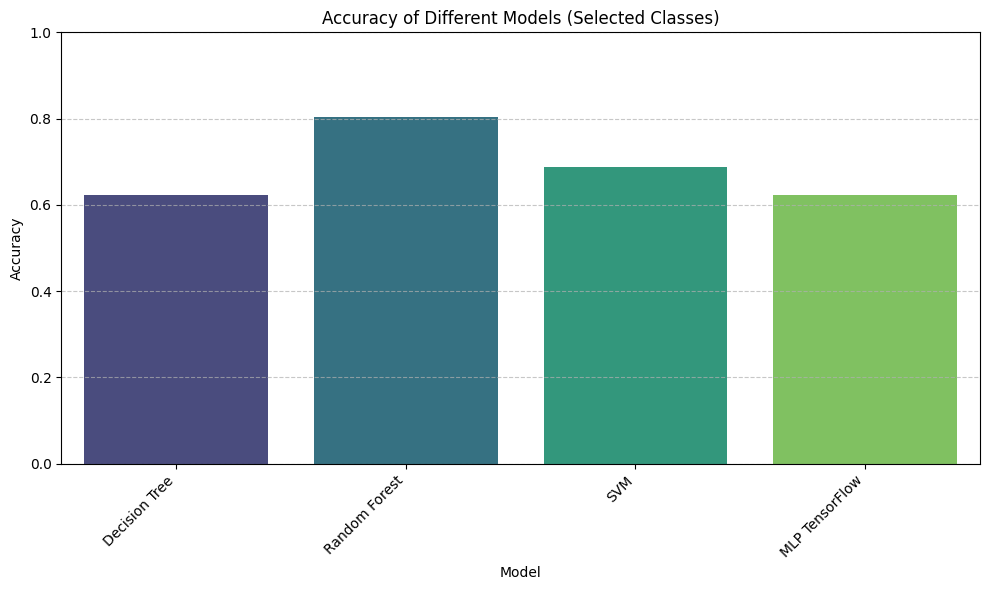

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df_selected.index, y='Accuracy', data=results_df_selected, palette='viridis', hue=results_df_selected.index)
plt.title('Accuracy of Different Models (Selected Classes)')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualización del comportamiento de los modelos

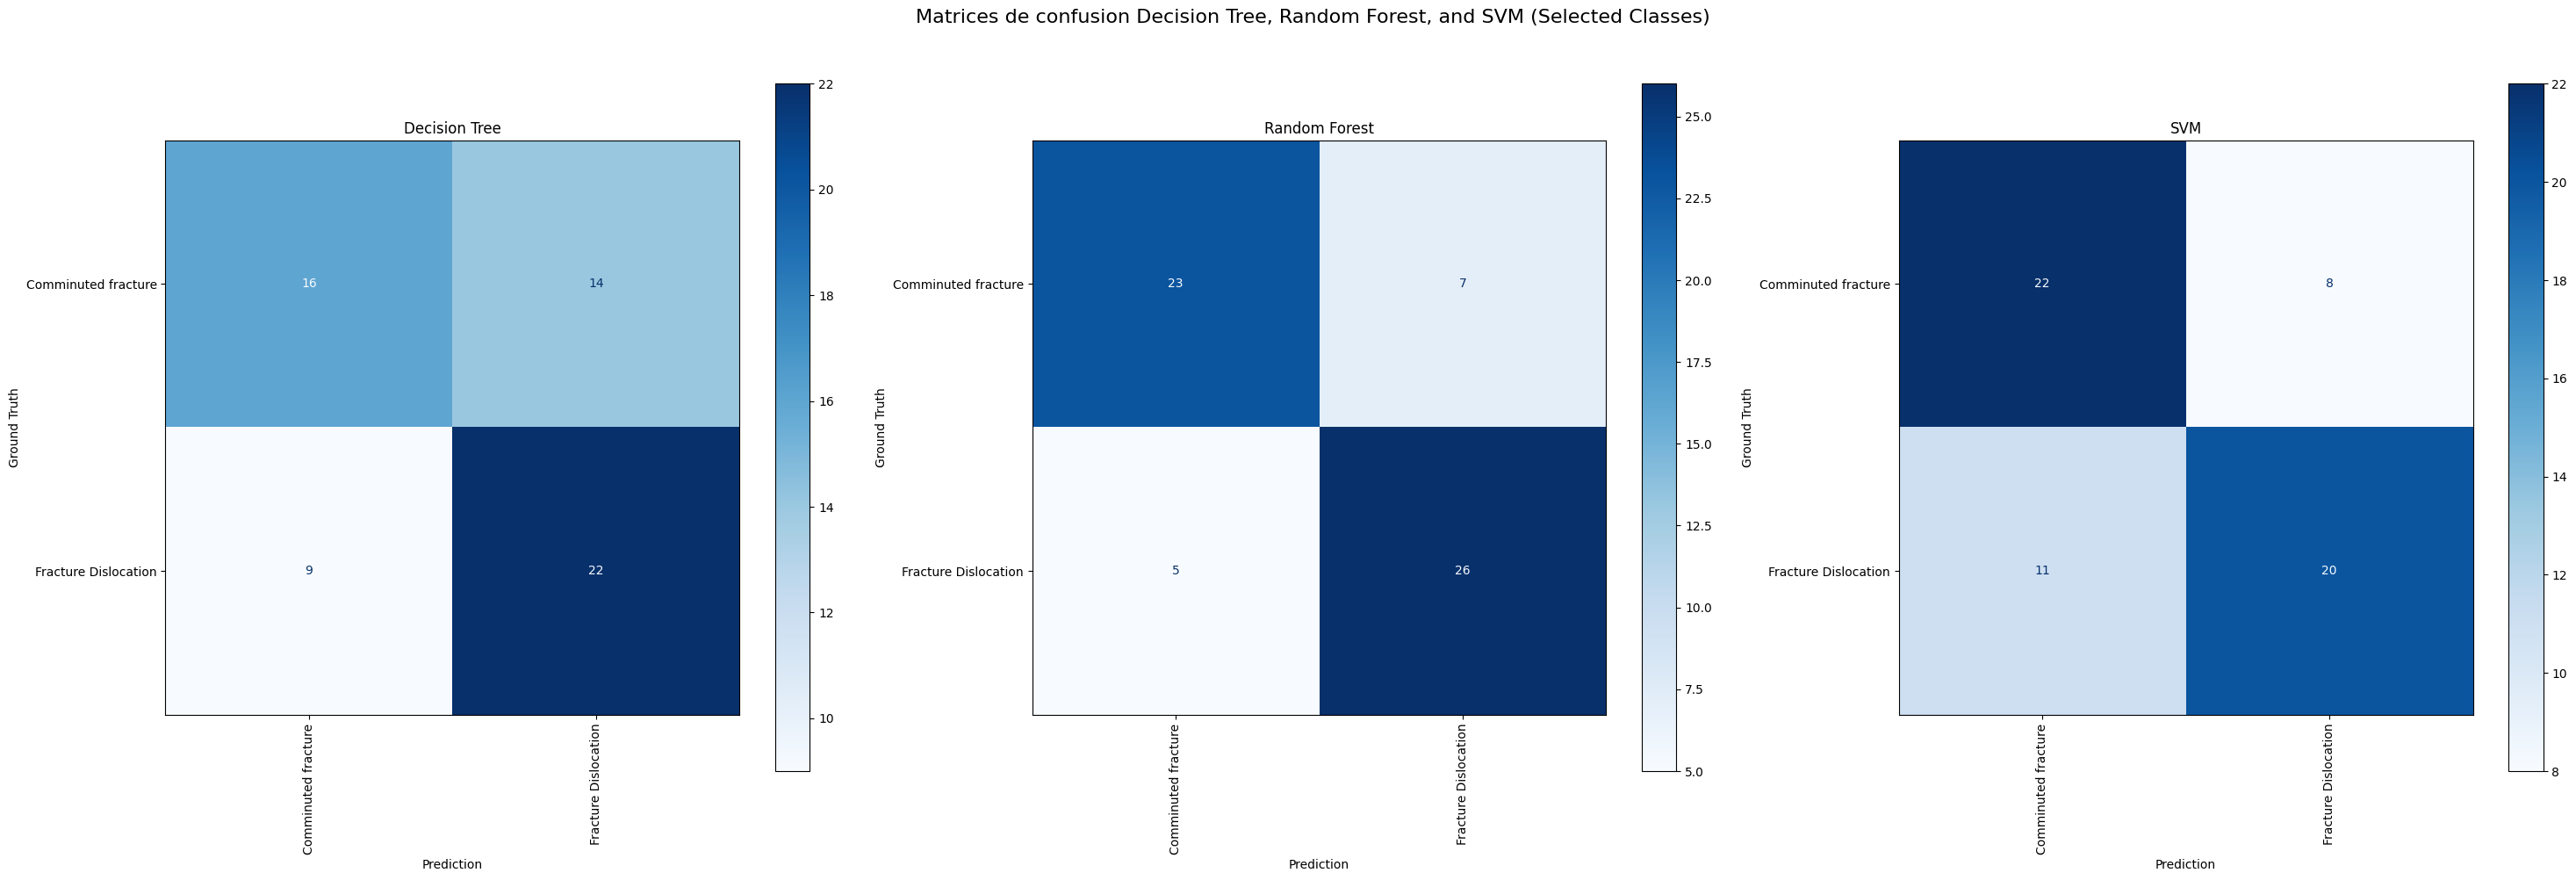

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix_subplot(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    ax.set_title(title)
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Ground Truth')

class_names_selected = le_selected.classes_

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
fig.suptitle('Matrices de confusion Decision Tree, Random Forest, and SVM (Selected Classes)', fontsize=16)

plot_confusion_matrix_subplot(y_test_selected, y_pred_dt_selected, class_names_selected, 'Decision Tree', axes[0])

plot_confusion_matrix_subplot(y_test_selected, y_pred_rf_selected, class_names_selected, 'Random Forest', axes[1])

plot_confusion_matrix_subplot(y_test_selected, y_pred_svm_selected, class_names_selected, 'SVM', axes[2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### MLP TensorFlow Historial de entrenamiento

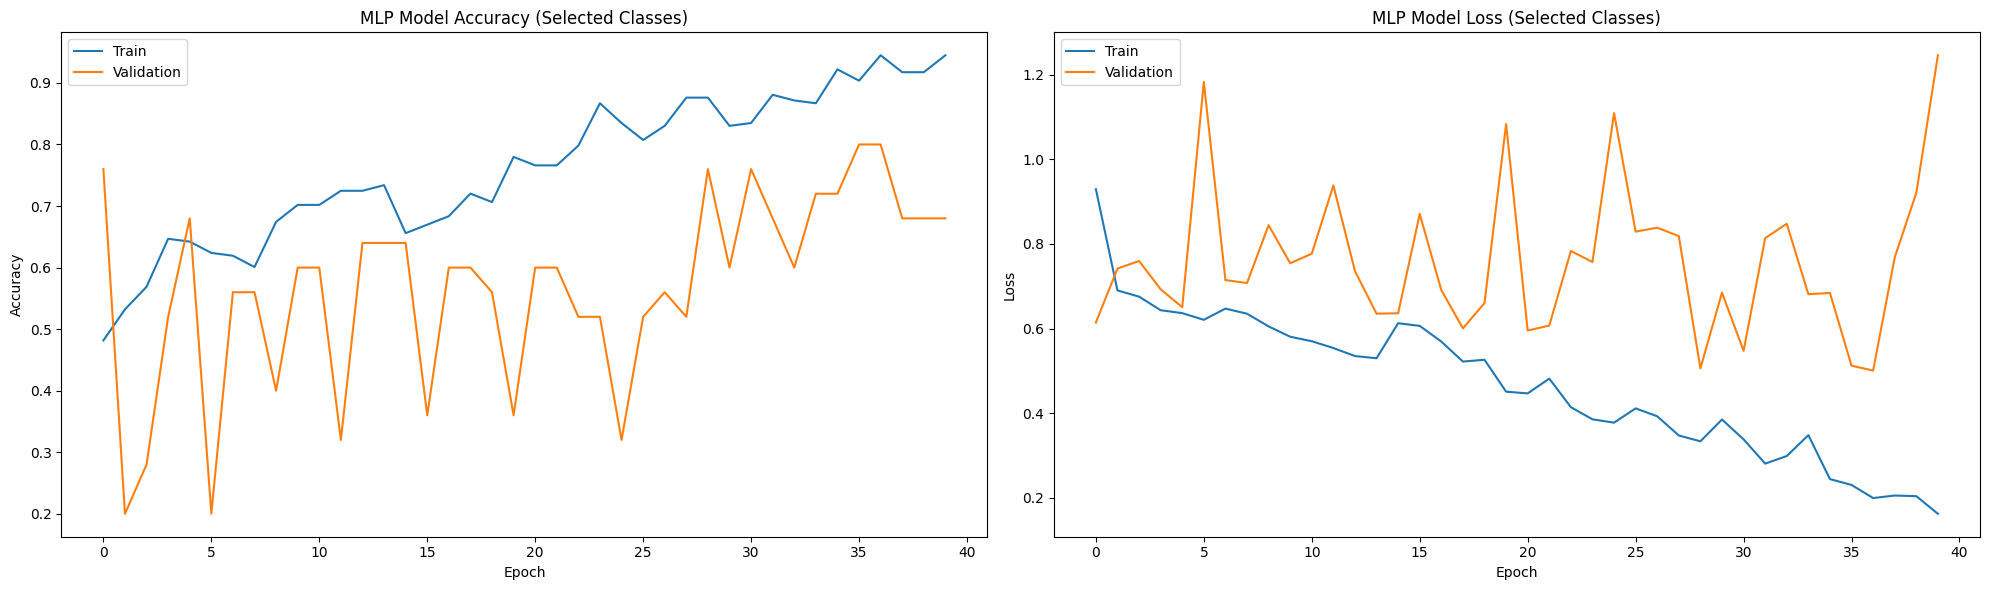

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

ax[0].plot(history_selected.history['accuracy'])
ax[0].plot(history_selected.history['val_accuracy'])
ax[0].set_title('MLP Model Accuracy (Selected Classes)')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history_selected.history['loss'])
ax[1].plot(history_selected.history['val_loss'])
ax[1].set_title('MLP Model Loss (Selected Classes)')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# **K-Means & DBSCAN**

### **Comparación de K-Means (k=2) vs Etiquetas Reales**

En esta sección, ejecutamos K-Means con el número exacto de clases seleccionadas y visualizamos la diferencia entre los clusters encontrados por el algoritmo y la clasificación médica real.

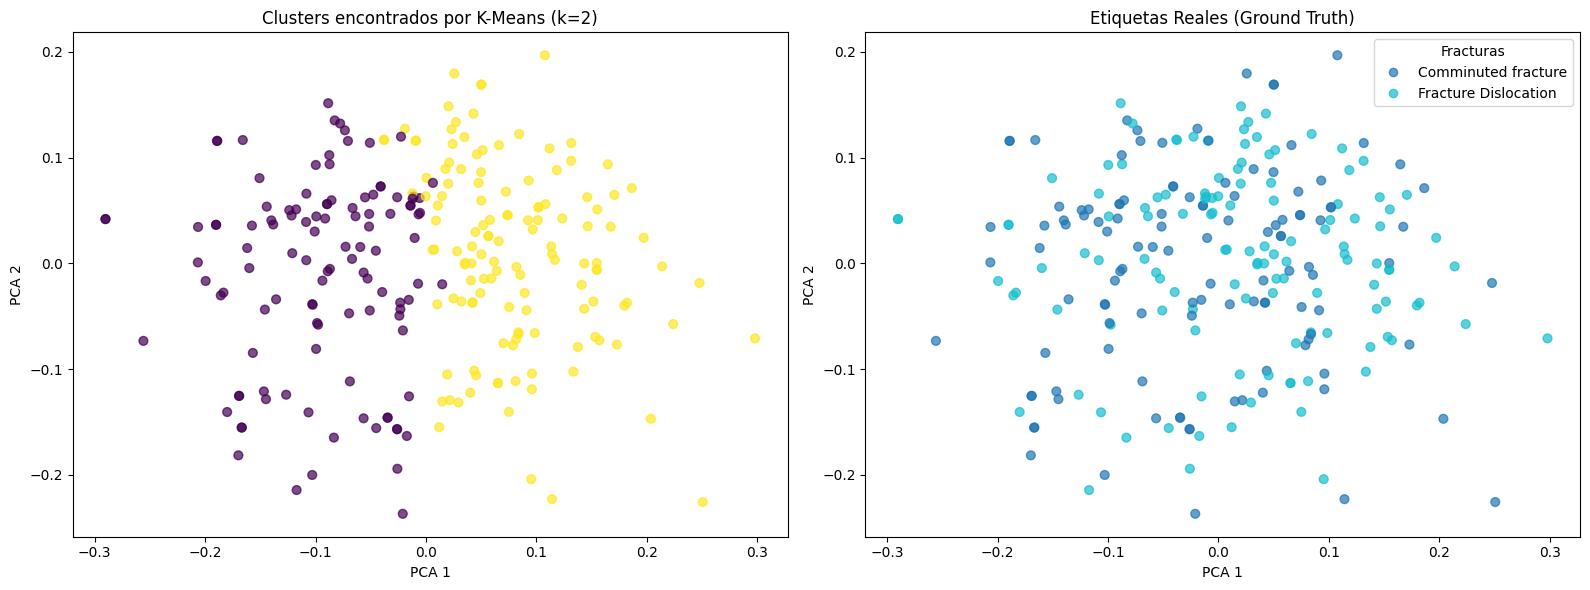

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_nn_selected)

k_clases = len(le_selected.classes_)
kmeans_final = KMeans(n_clusters=k_clases, random_state=42, n_init=10)
clusters_predict = kmeans_final.fit_predict(X_train_nn_selected)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_predict, cmap='viridis', s=40, alpha=0.7)
axes[0].set_title(f'Clusters encontrados por K-Means (k={k_clases})')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_selected, cmap='tab10', s=40, alpha=0.7)
axes[1].set_title('Etiquetas Reales (Ground Truth)')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')

handles, _ = scatter.legend_elements()
axes[1].legend(handles, le_selected.classes_, title="Fracturas", loc="best")

plt.tight_layout()
plt.show()

### **Análisis de los resultados de K-Means**

Al observar la comparación entre los clusters de K-Means y las etiquetas reales, podemos notar lo siguiente:

1.  **División Geométrica vs. Médica**: K-Means intenta agrupar los puntos basándose en la cercanía física en el espacio de características. Sin embargo, en el gráfico de la derecha (Ground Truth), vemos que las clases de fracturas están completamente traslapadas.
2.  **Traslape de Características**: Esto indica que la intensidad de los píxeles y las formas básicas capturadas por PCA no son suficientes para diferenciar una fractura de otra de forma no supervisada.
3.  **Limitación del Algoritmo**: K-Means asume que los clusters son esféricos y bien separados, lo cual no ocurre en este dataset médico donde la variabilidad intra-clase es alta y la inter-clase es baja.

La segmentación que hace K-Means es puramente matemática y carece de significado clínico en este espacio de baja dimensionalidad.

### **Análisis Detallado de DBSCAN**

Vamos a aplicar DBSCAN buscando una configuración que logre separar al menos algunos puntos, comparándolo con la distribución real de las fracturas.

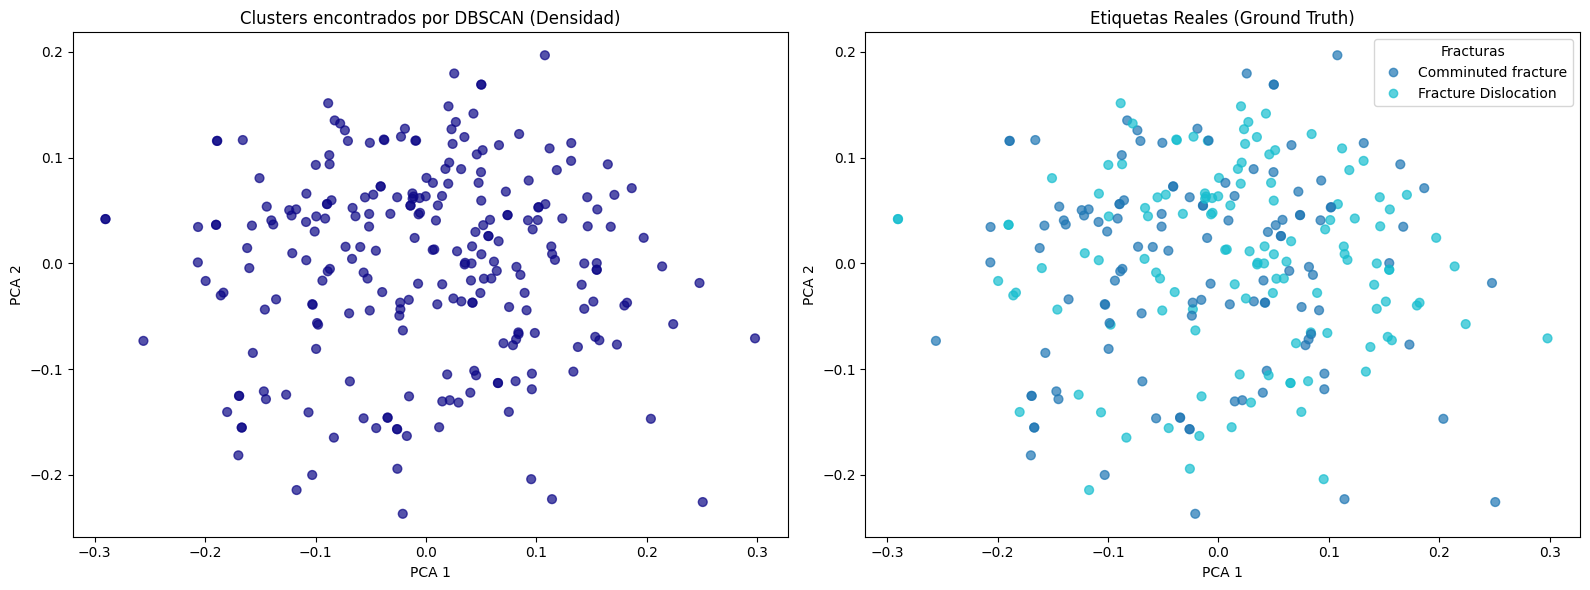

Número estimado de clusters: 1
Número estimado de puntos de ruido: 0 de 243


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_nn_selected)

dbscan_final = DBSCAN(eps=5.0, min_samples=5)
clusters_dbscan = dbscan_final.fit_predict(X_train_nn_selected)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, cmap='plasma', s=40, alpha=0.7)
axes[0].set_title('Clusters encontrados por DBSCAN (Densidad)')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_selected, cmap='tab10', s=40, alpha=0.7)
axes[1].set_title('Etiquetas Reales (Ground Truth)')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')

handles, _ = scatter.legend_elements()
axes[1].legend(handles, le_selected.classes_, title="Fracturas", loc="best")

plt.tight_layout()
plt.show()

n_clusters_ = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_ = list(clusters_dbscan).count(-1)
print(f'Número estimado de clusters: {n_clusters_}')
print(f'Número estimado de puntos de ruido: {n_noise_} de {len(clusters_dbscan)}')

Los resultados de DBSCAN confirman nuestra sospecha: el algoritmo no logró encontrar ningún cluster (identificó los 378 puntos como ruido).

Esto sucede porque DBSCAN requiere que existan zonas donde los puntos estén muy 'apretados' (densos) separadas por espacios vacíos. En este dataset de radiografías, las imágenes son tan similares entre sí que, al proyectarlas en 2D con PCA, forman una nube uniforme sin separaciones claras.

Conclusión del análisis de Clustering:

K-Means ($k=4$$k=4$): Logra dividir los datos artificialmente, pero sus grupos no coinciden con las categorías médicas, lo que indica que la geometría de los píxeles no refleja directamente el tipo de fractura.
DBSCAN: Falla al no encontrar variaciones de densidad significativas, tratando todo el conjunto como una sola masa de datos.
Esto refuerza la idea de que para este problema médico, los métodos tradicionales de visión por computadora basados en píxeles crudos no son suficientes y se requeriría aprendizaje profundo (Deep Learning) para extraer patrones más complejos.

# Visualizaciones adicionales

### **Visualización de la Separación de Clases Reales en el Espacio PCA**

Este gráfico muestra cómo se distribuyen las clases reales de fracturas en un espacio bidimensional reducido mediante PCA. Cada punto representa una imagen, y el color indica su tipo de fractura. Esto nos permite observar visualmente cuán distintas o superpuestas son las categorías en términos de las características extraídas por PCA.

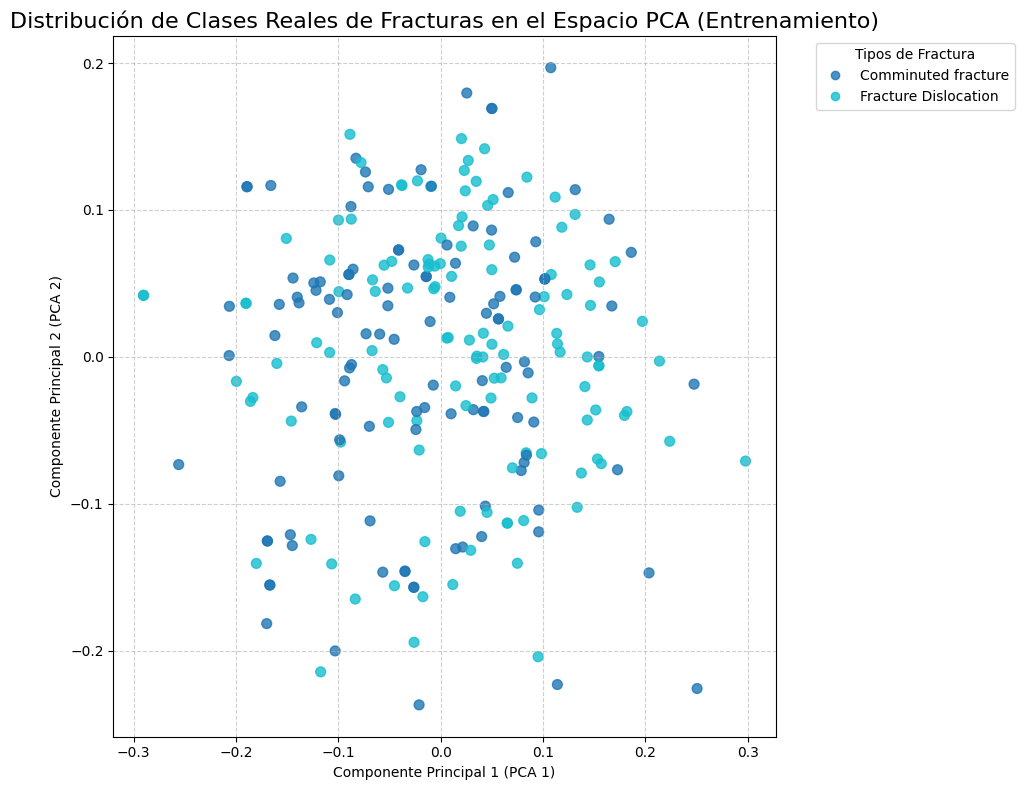

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_selected, cmap='tab10', s=50, alpha=0.8)

plt.title('Distribución de Clases Reales de Fracturas en el Espacio PCA (Entrenamiento)', fontsize=16)
plt.xlabel('Componente Principal 1 (PCA 1)')
plt.ylabel('Componente Principal 2 (PCA 2)')

handles, _ = scatter.legend_elements()
plt.legend(handles, le_selected.classes_, title='Tipos de Fractura', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **Visualización de la Separación de Clases Reales en el Espacio PCA (Todas las Clases)**

Este gráfico muestra cómo se distribuyen las 10 clases reales de fracturas en un espacio bidimensional reducido mediante PCA. Cada punto representa una imagen, y el color indica su tipo de fractura, permitiendo observar el nivel de distinción o superposición entre las categorías en función de las características de la imagen.

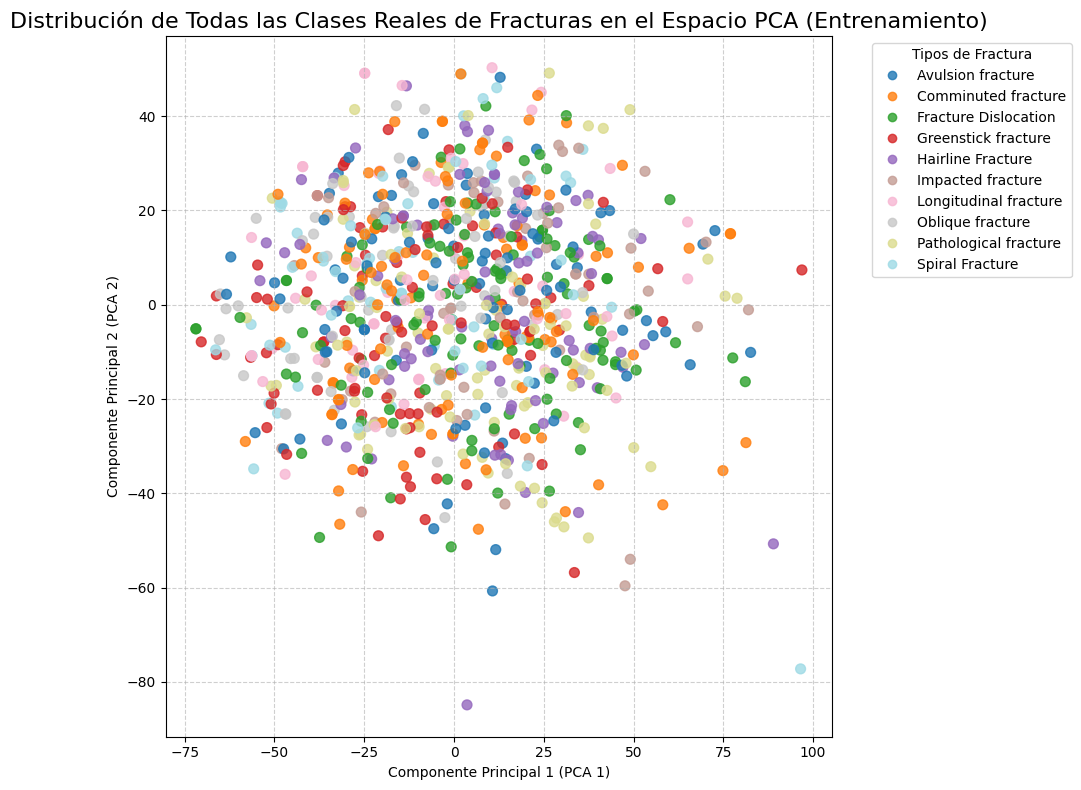

In [ ]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=2)
X_pca_full = pca_full.fit_transform(X_train)

plt.figure(figsize=(10, 8))
scatter_full = plt.scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=y_train, cmap='tab20', s=50, alpha=0.8)

plt.title('Distribución de Todas las Clases Reales de Fracturas en el Espacio PCA (Entrenamiento)', fontsize=16)
plt.xlabel('Componente Principal 1 (PCA 1)')
plt.ylabel('Componente Principal 2 (PCA 2)')

handles_full, _ = scatter_full.legend_elements()
plt.legend(handles_full, le.classes_, title='Tipos de Fractura', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()